# 03 · Análisis Exploratorio (series en niveles, sin transformar)
**Tesis:** Medición del ciclo financiero en Perú
**Autor:** Roberto Samaniego | **Asesor:** Dr. Sergio Camiz

---

**Responsabilidad única de este notebook:** visualizar las series y su estructura
de correlación **en niveles**, tal como están en `data/raw/`, antes de aplicar
cualquier transformación de estacionariedad o estandarización.

Esto le permite a tu asesor ver primero el comportamiento crudo de los datos.
Cualquier `dropna()` usado aquí es **local** al cálculo de una figura (p. ej.
la matriz de correlación necesita casos completos) y no se guarda como un
nuevo dataset ni sobrescribe `df_raw`.

## 1. Librerías y carga de datos verificados

In [1]:

import os
os.chdir(os.path.expanduser('~/Documents/tesis-ciclo-financiero-peru'))
print(os.getcwd())
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('data/raw/series_bcrp_raw.csv', index_col=0, parse_dates=True)
print(f'Dataset: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas (niveles originales)')

/Users/robert/Documents/tesis-ciclo-financiero-peru
Dataset: 228 filas x 18 columnas (niveles originales)


## 2. Bloques temáticos para la visualización

In [2]:
BLOQUES = {
    'Crédito':   ['Crédito SF sector privado', 'Crédito empresarial',
                  'Crédito consumo', 'Crédito hipotecario'],
    'Tasas':     ['Tasa activa TAMN', 'Tasa pasiva TIPMN', 'Tasa referencia BCRP'],
    'TC y mercado': ['Tipo de cambio', 'Índice BVL', 'IPC Lima'],
    'Actividad': ['PBI desestacionalizado', 'Demanda interna', 'Reservas internacionales'],
}
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

## 3. Visualización de series en niveles

Guardado en reports/figures/03_series_niveles_bcrp_juntos.png


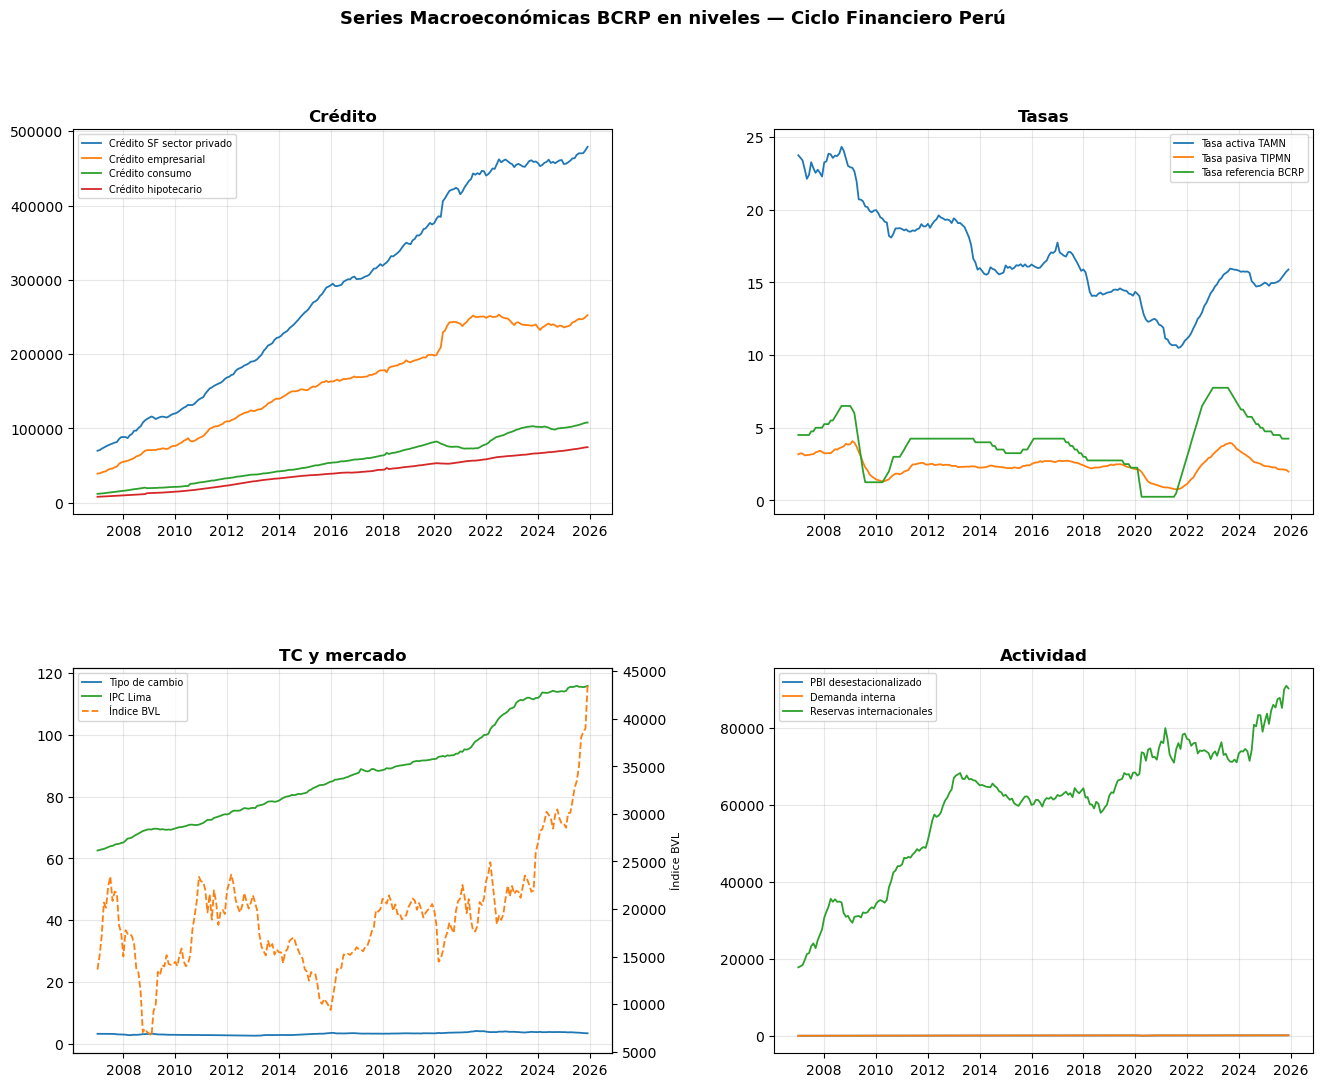

In [3]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Series Macroeconómicas BCRP en niveles — Ciclo Financiero Perú',
             fontsize=13, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# Bloque 'TC y mercado': el Índice BVL tiene una escala muy distinta
# (decenas de miles de puntos) a Tipo de cambio e IPC Lima (unidades/cientos).
# Se usa un eje Y secundario solo para visualización -- no modifica los datos.
for idx, (bloque, nombres) in enumerate(BLOQUES.items()):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])

    if bloque == 'TC y mercado':
        ax2 = ax.twinx()
        for i, nombre in enumerate(nombres):
            if nombre not in df_raw.columns:
                continue
            if nombre == 'Índice BVL':
                ax2.plot(df_raw.index, df_raw[nombre], label=nombre,
                         color=colores[i % len(colores)], linewidth=1.3, linestyle='--')
                ax2.set_ylabel('Índice BVL', fontsize=8)
            else:
                ax.plot(df_raw.index, df_raw[nombre], label=nombre,
                        color=colores[i % len(colores)], linewidth=1.3)
        lineas1, etiquetas1 = ax.get_legend_handles_labels()
        lineas2, etiquetas2 = ax2.get_legend_handles_labels()
        ax.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, fontsize=7, loc='upper left')
    else:
        for i, nombre in enumerate(nombres):
            if nombre in df_raw.columns:
                ax.plot(df_raw.index, df_raw[nombre], label=nombre,
                        color=colores[i % len(colores)], linewidth=1.3)
        ax.legend(fontsize=7)

    ax.set_title(bloque, fontweight='bold')
    ax.grid(True, alpha=0.3)

os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/03_series_niveles_bcrp.png', dpi=150, bbox_inches='tight')
print('Guardado en reports/figures/03_series_niveles_bcrp_juntos.png')
plt.show()

## 4. Matriz de correlaciones (niveles, casos completos)

El `dropna()` de esta celda es transitorio: se usa solo para calcular la
correlación (que requiere casos completos) y no se reasigna a `df_raw`
ni se guarda como archivo nuevo.

Guardado en reports/figures/03_correlaciones_niveles_bcrp.png

Observación: n=228 casos completos usados solo para esta figura.


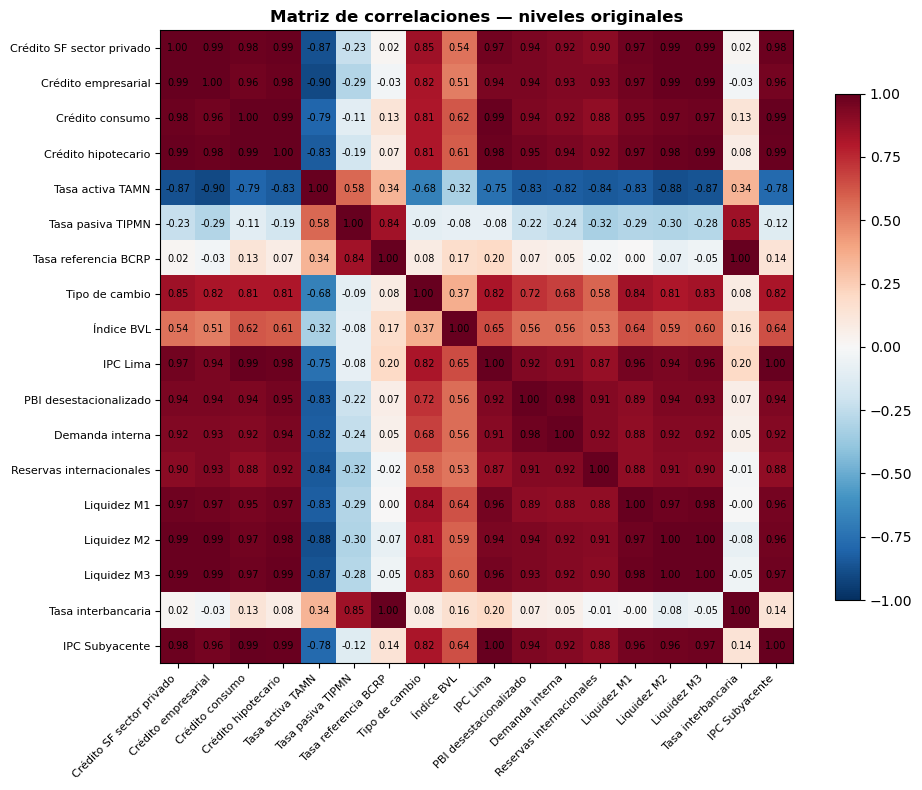

In [4]:
df_para_corr = df_raw.dropna()  # transitorio, solo para esta figura
corr = df_para_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriz de correlaciones — niveles originales', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/03_correlaciones_niveles_bcrp.png', dpi=150, bbox_inches='tight')
print('Guardado en reports/figures/03_correlaciones_niveles_bcrp.png')
print(f'\nObservación: n={len(df_para_corr)} casos completos usados solo para esta figura.')
plt.show()

## Nota metodológica

Este análisis exploratorio trabaja siempre sobre niveles originales.
Las transformaciones para estacionariedad (logaritmo, diferencias) y la
estandarización se realizan en `04_preprocesamiento.ipynb`, que es la
única etapa donde el dataset cambia de forma.

Guardado en reports/figures/03_series_niveles_bcrp_individuales.png


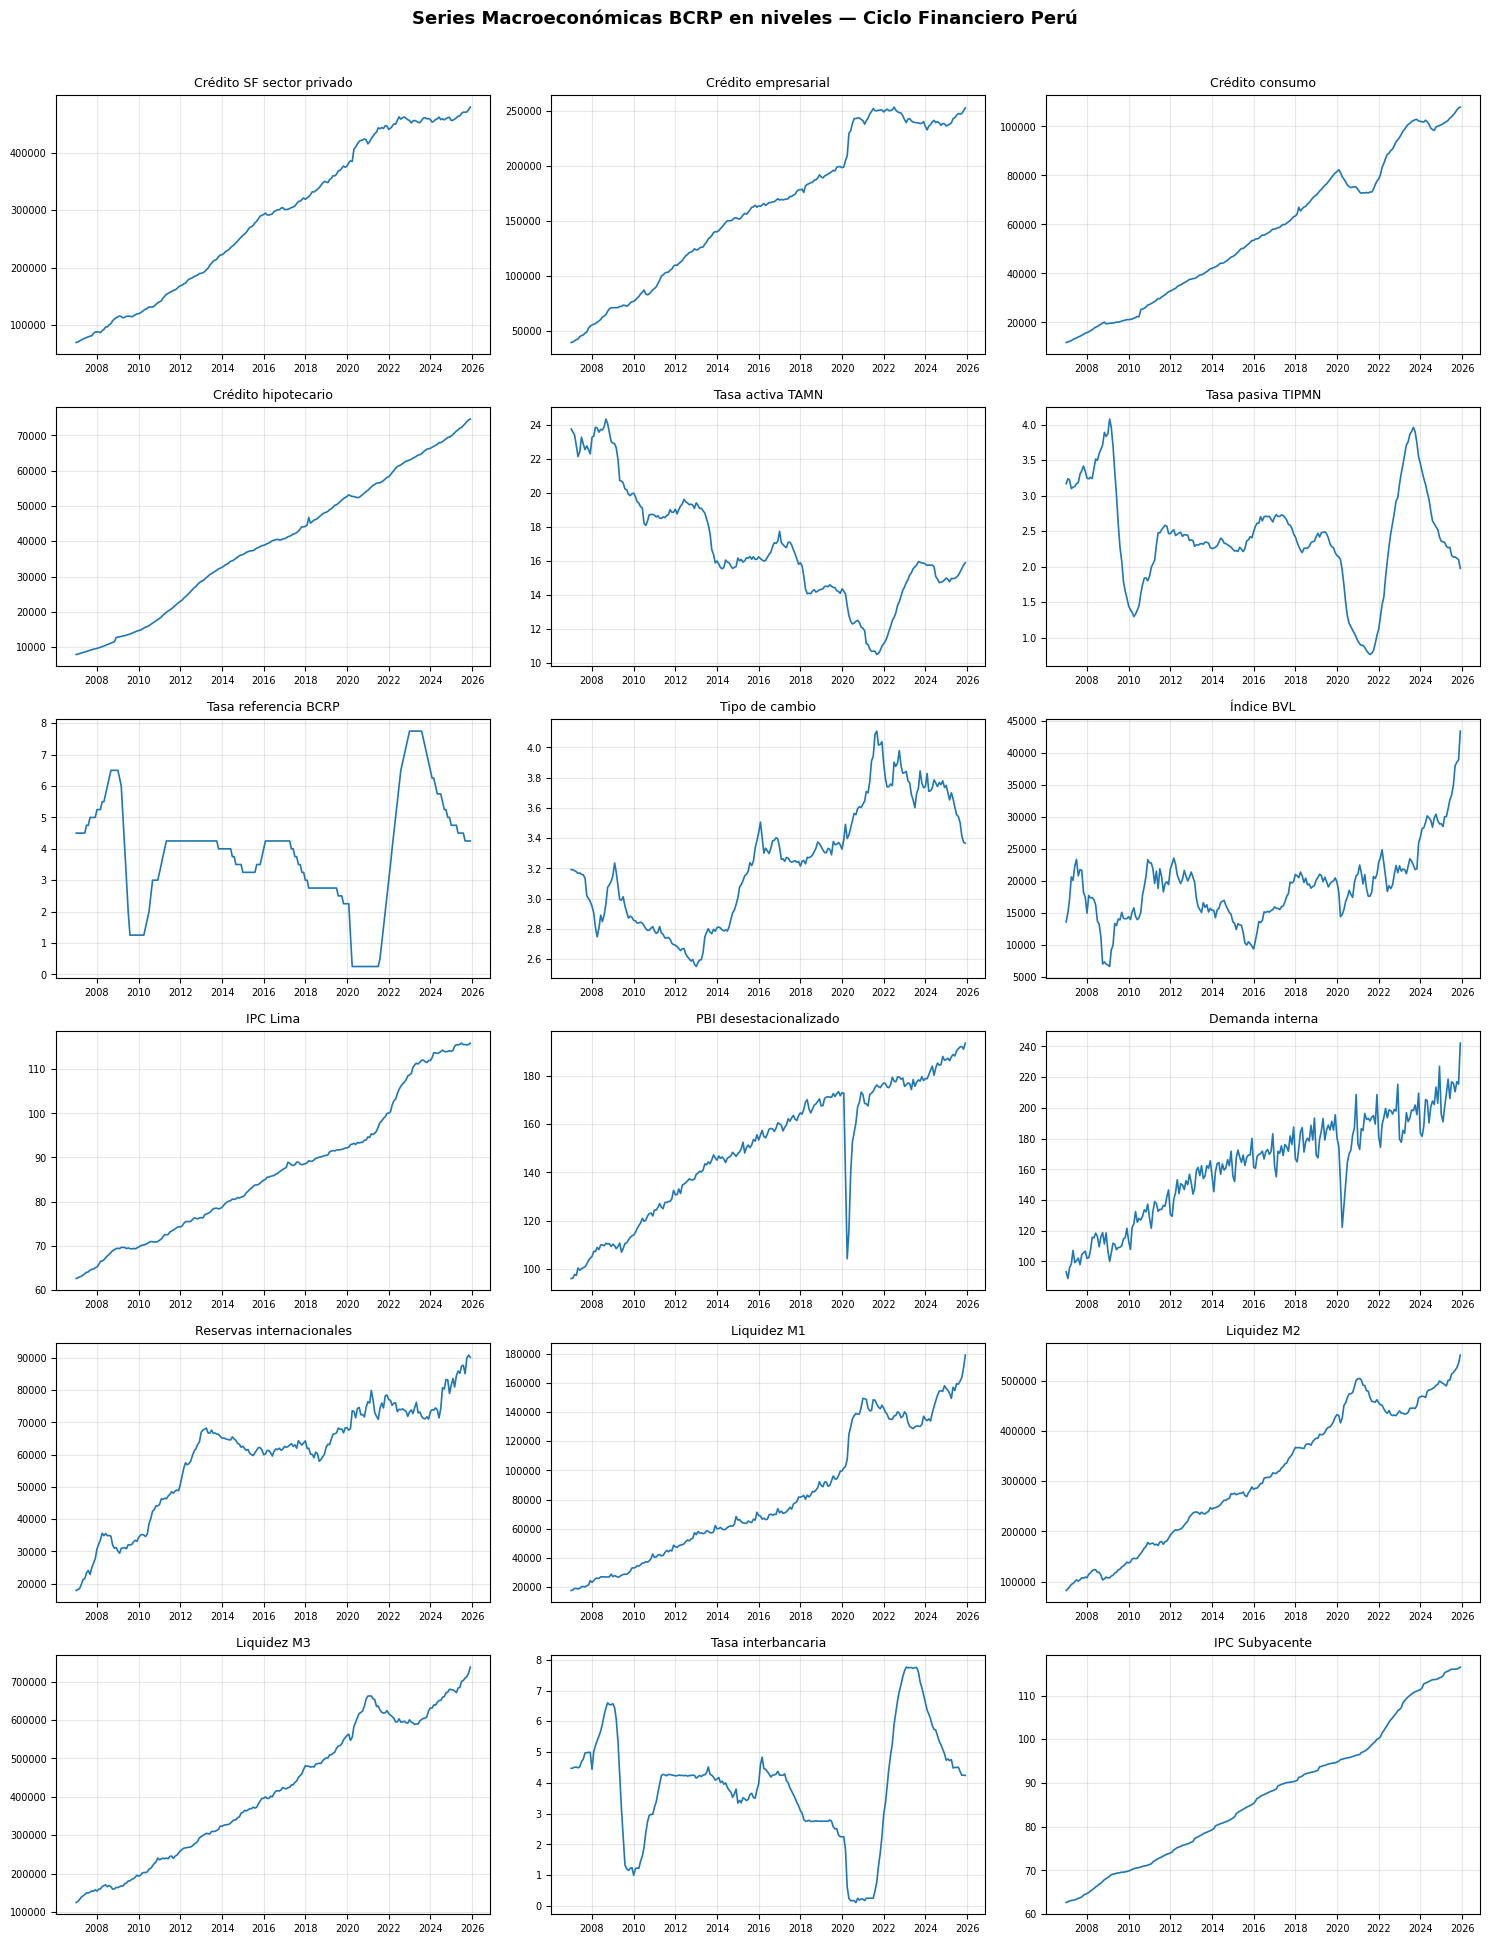

In [5]:
# Un subplot por serie (no agrupadas por bloque) -- así cada una usa su propia
# escala automática y ninguna se oculta por diferencias de magnitud
# (crédito en miles de millones, tasas en %, tipo de cambio ~3-4, índices ~100,
# reservas en miles de millones de US$, etc.)

series_a_graficar = list(df_raw.columns)
n_series = len(series_a_graficar)
n_cols = 3
n_rows = int(np.ceil(n_series / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.2 * n_rows))
fig.suptitle('Series Macroeconómicas BCRP en niveles — Ciclo Financiero Perú',
             fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, nombre in enumerate(series_a_graficar):
    axes[i].plot(df_raw.index, df_raw[nombre], color='#1f77b4', linewidth=1.2)
    axes[i].set_title(nombre, fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

# ocultar subplots vacíos si el número de series no llena la grilla completa
for j in range(n_series, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/03_series_niveles_bcrp.png', dpi=150, bbox_inches='tight')
print('Guardado en reports/figures/03_series_niveles_bcrp_individuales.png')
plt.show()